# Project: Wrangling and Analyze Data

## Data Gathering
In the cell below, gather **all** three pieces of data for this project and load them in the notebook. **Note:** the methods required to gather each data are different.
1. Directly download the WeRateDogs Twitter archive data (twitter_archive_enhanced.csv)

In [3]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [1855]:
# import packages 
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

In [1857]:
# load the data into pandas dataframe
df_archive_enhanced = pd.read_csv('twitter-archive-enhanced.csv')
# View the head of the dataframe
df_archive_enhanced.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643555336193/photo/1,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421306343426/photo/1,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181378084864/photo/1,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557279858688/photo/1,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",NaN,NaN,NaN,"https://twitter.com/dog_rates/status/891327558926688256/photo/1,https://twitter.com/dog_rates/status/891327558926688256/photo/1",12,10,Franklin,NaN,NaN,NaN,NaN


2. Use the Requests library to download the tweet image prediction (image_predictions.tsv)

In [1860]:
# download the image prediction file
url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'
response = requests.get(url)
file = open(url.split('/')[-1],mode='wb')
file.write(response.content)
file.close()

In [1861]:
# open in the file in a pandas dataframe with a tab(\t) separator
df_image_prediction = pd.read_csv('image-predictions.tsv',sep='\t')
# View the head of the datadrame
df_image_prediction.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


3. Use the Tweepy library to query additional data via the Twitter API (tweet_json.txt)<br>
**(Here I'll access the data necessary for the project from `tweet_json.txt` file )**

In [1863]:
tweets_list = []
# # open the file and read it in read mode
with open('tweet-json.txt',mode='r') as file:
    for line in file:
        # convert  each piece of the file to JSON and extract the information from it
        tweet_json = json.loads(line)
        # Make a new dictionary for each tweet
        tweets_dict = {}
        tweets_dict['tweet_id'] = tweet_json['id']
        # get the timestamp to check for tweets beyond August 1st, 2017
        tweets_dict['timestamp'] = tweet_json['created_at'] 
        tweets_dict['retweet_count'] = tweet_json['retweet_count']
        tweets_dict['favorite_count'] = tweet_json['favorite_count']
        tweets_dict['retweeted'] = tweet_json['retweeted']
        # Append the data to the list to make a list of dictionaries
        tweets_list.append(tweets_dict)

In [1864]:
# Make a pandas dataframe for the data I extracted 
df_tweets = pd.DataFrame(data=tweets_list)
df_tweets.head()

,tweet_id,timestamp,retweet_count,favorite_count,retweeted
0,892420643555336193,Tue Aug 01 16:23:56 +0000 2017,8853,39467,False
1,892177421306343426,Tue Aug 01 00:17:27 +0000 2017,6514,33819,False
2,891815181378084864,Mon Jul 31 00:18:03 +0000 2017,4328,25461,False
3,891689557279858688,Sun Jul 30 15:58:51 +0000 2017,8964,42908,False
4,891327558926688256,Sat Jul 29 16:00:24 +0000 2017,9774,41048,False


## Assessing Data
In this section, detect and document at least **eight (8) quality issues and two (2) tidiness issue**. You must use **both** visual assessment
programmatic assessement to assess the data.

**Note:** pay attention to the following key points when you access the data.

* You only want original ratings (no retweets) that have images. Though there are 5000+ tweets in the dataset, not all are dog ratings and some are retweets.
* Assessing and cleaning the entire dataset completely would require a lot of time, and is not necessary to practice and demonstrate your skills in data wrangling. Therefore, the requirements of this project are only to assess and clean at least 8 quality issues and at least 2 tidiness issues in this dataset.
* The fact that the rating numerators are greater than the denominators does not need to be cleaned. This [unique rating system](http://knowyourmeme.com/memes/theyre-good-dogs-brent) is a big part of the popularity of WeRateDogs.
* You do not need to gather the tweets beyond August 1st, 2017. You can, but note that you won't be able to gather the image predictions for these tweets since you don't have access to the algorithm used.



### Assessing `df_rachive_enhanced` Dataframe programmatically

In [1867]:
# Use head() method to view the first five rows of the dataframe
df_archive_enhanced.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643555336193/photo/1,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421306343426/photo/1,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181378084864/photo/1,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557279858688/photo/1,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",NaN,NaN,NaN,"https://twitter.com/dog_rates/status/891327558926688256/photo/1,https://twitter.com/dog_rates/status/891327558926688256/photo/1",12,10,Franklin,NaN,NaN,NaN,NaN


In [1868]:
# use sample () method to view samples from the dataframe
df_archive_enhanced.sample()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
628,794926597468000259,NaN,NaN,2016-11-05 15:37:24 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Mack. He's rather h*ckin sleepy. Exceptional ears. 12/10 would boop https://t.co/XRPvTPF0VH,NaN,NaN,NaN,https://twitter.com/dog_rates/status/794926597468000259/photo/1,12,10,Mack,NaN,NaN,NaN,NaN


there is html element with the URLs of the `source` column

In [1870]:
df_archive_enhanced.describe()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,retweeted_status_id,retweeted_status_user_id,rating_numerator,rating_denominator
count,2.356000e+03,7.800000e+01,7.800000e+01,1.810000e+02,1.810000e+02,2356.000000,2356.000000
mean,7.427716e+17,7.455079e+17,2.014171e+16,7.720400e+17,1.241698e+16,13.126486,10.455433
std,6.856705e+16,7.582492e+16,1.252797e+17,6.236928e+16,9.599254e+16,45.876648,6.745237
min,6.660209e+17,6.658147e+17,1.185634e+07,6.661041e+17,7.832140e+05,0.000000,0.000000
25%,6.783989e+17,6.757419e+17,3.086374e+08,7.186315e+17,4.196984e+09,10.000000,10.000000
50%,7.196279e+17,7.038708e+17,4.196984e+09,7.804657e+17,4.196984e+09,11.000000,10.000000
75%,7.993373e+17,8.257804e+17,4.196984e+09,8.203146e+17,4.196984e+09,12.000000,10.000000
max,8.924206e+17,8.862664e+17,8.405479e+17,8.874740e+17,7.874618e+17,1776.000000,170.000000


In [1871]:
# use info() method to view information about the dataframe
df_archive_enhanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        1611 non-null   object 
 13  doggo                       97 no

`timestamp` and `retweeted_status_timestamp` columns are  Datetime datatype not  object

In [1873]:
# Use the isnull() method to view the null values in the dataframe
df_archive_enhanced.isnull().sum()

tweet_id                         0
in_reply_to_status_id         2278
in_reply_to_user_id           2278
timestamp                        0
source                           0
text                             0
retweeted_status_id           2175
retweeted_status_user_id      2175
retweeted_status_timestamp    2175
expanded_urls                   59
rating_numerator                 0
rating_denominator               0
name                           745
doggo                         2259
floofer                       2346
pupper                        2099
puppo                         2326
dtype: int64

- AS we can see, there is a lot of missing data in `in_reply_to_status_id` , `in_reply_to_user_id`, `retweeted_status_id`, `retweeted_status_user_id`, , `name`, `doggo`, `floofer`, `pupper`, and `puppo`
- there are a few missing values in the `expanded_urls`

In [1875]:
# check if there are any retweeted records
df_archive_enhanced[df_archive_enhanced['retweeted_status_id'].notna()]

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
19,888202515573088257,NaN,NaN,2017-07-21 01:02:36 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @dog_rates: This is Canela. She attempted some fancy porch pics. They were unsuccessful. 13/10 someone help her https://t.co/cLyzpcUcMX,8.874740e+17,4.196984e+09,2017-07-19 00:47:34 +0000,"https://twitter.com/dog_rates/status/887473957103951883/photo/1,https://twitter.com/dog_rates/status/887473957103951883/photo/1,https://twitter.com/dog_rates/status/887473957103951883/photo/1,https://twitter.com/dog_rates/status/887473957103951883/photo/1",13,10,Canela,NaN,NaN,NaN,NaN
32,886054160059072513,NaN,NaN,2017-07-15 02:45:48 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @Athletics: 12/10 #BATP https://t.co/WxwJmvjfxo,8.860537e+17,1.960740e+07,2017-07-15 02:44:07 +0000,"https://twitter.com/dog_rates/status/886053434075471873,https://twitter.com/dog_rates/status/886053434075471873",12,10,NaN,NaN,NaN,NaN,NaN
36,885311592912609280,NaN,NaN,2017-07-13 01:35:06 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @dog_rates: This is Lilly. She just parallel barked. Kindly requests a reward now. 13/10 would pet so well https://t.co/SATN4If5H5,8.305833e+17,4.196984e+09,2017-02-12 01:04:29 +0000,"https://twitter.com/dog_rates/status/830583320585068544/photo/1,https://twitter.com/dog_rates/status/830583320585068544/photo/1,https://twitter.com/dog_rates/status/830583320585068544/photo/1,https://twitter.com/dog_rates/status/830583320585068544/photo/1",13,10,Lilly,NaN,NaN,NaN,NaN
68,879130579576475649,NaN,NaN,2017-06-26 00:13:58 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @dog_rates: This is Emmy. She was adopted today. Massive round of pupplause for Emmy and her new family. 14/10 for all involved https://…,8.780576e+17,4.196984e+09,2017-06-23 01:10:23 +0000,"https://twitter.com/dog_rates/status/878057613040115712/photo/1,https://twitter.com/dog_rates/status/878057613040115712/photo/1",14,10,Emmy,NaN,NaN,NaN,NaN
73,878404777348136964,NaN,NaN,2017-06-24 00:09:53 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","RT @dog_rates: Meet Shadow. In an attempt to reach maximum zooming borkdrive, he tore his ACL. Still 13/10 tho. Help him out below\n\nhttps:/…",8.782815e+17,4.196984e+09,2017-06-23 16:00:04 +0000,"https://www.gofundme.com/3yd6y1c,https://twitter.com/dog_rates/status/878281511006478336/photo/1",13,10,Shadow,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,746521445350707200,NaN,NaN,2016-06-25 01:52:36 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @dog_rates: This is Shaggy. He knows exactly how to solve the puzzle but can't talk. All he wants to do is help. 10/10 great guy https:/…,6.678667e+17,4.196984e+09,2015-11-21 00:46:50 +0000,https://twitter.com/dog_rates/status/667866724293877760/photo/1,10,10,Shaggy,NaN,NaN,NaN,NaN
1043,743835915802583040,NaN,NaN,2016-06-17 16:01:16 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @dog_rates: Extremely intelligent dog here. Has learned to walk like human. Even has his own dog. Very impressive 10/10 https://t.co/0Dv…,6.671383e+17,4.196984e+09,2015-11-19 00:32:12 +0000,https://twitter.com/dog_rates/status/667138269671505920/photo/1,10,10,NaN,NaN,NaN,NaN,NaN
1242,711998809858043904,NaN,NaN,2016-03-21 19:31:59 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @twitter: @dog_rates Awesome Tweet! 12/10. Would Retweet. #LoveTwitter https://t.co/j6FQGhxYuN

As we can see there are some records which are  retweeted posts

In [1877]:
# Use duplicated() method to know if there are duplicates in the dataframe
sum(df_archive_enhanced.duplicated())

0

there are no duplicates in this dataframe

In [1879]:
print(len(df_archive_enhanced[df_archive_enhanced['name'] == 'a']))
print(len(df_archive_enhanced[df_archive_enhanced['name'] == 'an']))
print(len(df_archive_enhanced[df_archive_enhanced['name'] == 'the']))

55
7
8


As we can see there are uncompleted dog names in the `name` column **(This issue was found while visual assessing)**

### Assessing `df_image_prediction` Dataframe programmatically

In [1882]:
# Use head() method to view the first five rows of the dataframe
df_image_prediction.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


In [1883]:
# view descriptive statistics about the dataframe
df_image_prediction.describe()

,tweet_id,img_num,p1_conf,p2_conf,p3_conf
count,2.075000e+03,2075.000000,2075.000000,2.075000e+03,2.075000e+03
mean,7.384514e+17,1.203855,0.594548,1.345886e-01,6.032417e-02
std,6.785203e+16,0.561875,0.271174,1.006657e-01,5.090593e-02
min,6.660209e+17,1.000000,0.044333,1.011300e-08,1.740170e-10
25%,6.764835e+17,1.000000,0.364412,5.388625e-02,1.622240e-02
50%,7.119988e+17,1.000000,0.588230,1.181810e-01,4.944380e-02
75%,7.932034e+17,1.000000,0.843855,1.955655e-01,9.180755e-02
max,8.924206e+17,4.000000,1.000000,4.880140e-01,2.734190e-01


In [1884]:
# look for any non-dog entities  in the predictions (p1,p2,p3) 
df_image_prediction[(df_image_prediction['p1_dog'] == False) & (df_image_prediction['p2_dog'] == False) & (df_image_prediction['p3_dog'] == False)]

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
6,666051853826850816,https://pbs.twimg.com/media/CT5KoJ1WoAAJash.jpg,1,box_turtle,0.933012,False,mud_turtle,0.045885,False,terrapin,0.017885,False
17,666104133288665088,https://pbs.twimg.com/media/CT56LSZWoAAlJj2.jpg,1,hen,0.965932,False,cock,0.033919,False,partridge,0.000052,False
18,666268910803644416,https://pbs.twimg.com/media/CT8QCd1WEAADXws.jpg,1,desktop_computer,0.086502,False,desk,0.085547,False,bookcase,0.079480,False
21,666293911632134144,https://pbs.twimg.com/media/CT8mx7KW4AEQu8N.jpg,1,three-toed_sloth,0.914671,False,otter,0.015250,False,great_grey_owl,0.013207,False
25,666362758909284353,https://pbs.twimg.com/media/CT9lXGsUcAAyUFt.jpg,1,guinea_pig,0.996496,False,skunk,0.002402,False,hamster,0.000461,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2021,880935762899988482,https://pbs.twimg.com/media/DDm2Z5aXUAEDS2u.jpg,1,street_sign,0.251801,False,umbrella,0.115123,False,traffic_light,0.069534,False
2022,881268444196462592,https://pbs.twimg.com/media/DDrk-f9WAAI-WQv.jpg,1,tusker,0.473303,False,Indian_elephant,0.245646,False,ibex,0.055661,False
2046,886680336477933568,https://pbs.twimg.com/media/DE4fEDzWAAAyHMM.jpg,1,convertible,0.738995,False,sports_car,0.139952,False,car_wheel,0.044173,False
2052,887517139158093824,https://pbs.twimg.com/ext_tw_video_thumb/887517108413886465/pu/img/WanJKwssZj4VJvL9.jpg,1,limousine,0.130432,False,tow_truck,0.029175,False,shopping_cart,0.026321,False


there are non-dog records accourding to the prediction , these records are not important since our data must be for dogs

In [1886]:
# use sample() method to view samples from the dataframe
df_image_prediction.sample()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
1992,873697596434513921,https://pbs.twimg.com/media/DA7iHL5U0AA1OQo.jpg,1,laptop,0.153718,False,French_bulldog,0.099984,True,printer,0.07713,False


In [1887]:
# use info() method to view information about the dataframe
df_image_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   int64  
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


In [1888]:
# Use the duplicated() method to know if there are duplicates in the dataframe
sum(df_image_prediction.duplicated())

0

### Assessing `df_tweets` dataframe prgrammatically

In [1894]:
 # view the first few rows of the dataframe
df_tweets.head()

,tweet_id,timestamp,retweet_count,favorite_count,retweeted
0,892420643555336193,Tue Aug 01 16:23:56 +0000 2017,8853,39467,False
1,892177421306343426,Tue Aug 01 00:17:27 +0000 2017,6514,33819,False
2,891815181378084864,Mon Jul 31 00:18:03 +0000 2017,4328,25461,False
3,891689557279858688,Sun Jul 30 15:58:51 +0000 2017,8964,42908,False
4,891327558926688256,Sat Jul 29 16:00:24 +0000 2017,9774,41048,False


In [1895]:
# check if there are any retweeted records
df_tweets[df_tweets['retweeted'] == True]

,tweet_id,timestamp,retweet_count,favorite_count,retweeted


In [1896]:
# View information about the dataframe
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        2354 non-null   int64 
 1   timestamp       2354 non-null   object
 2   retweet_count   2354 non-null   int64 
 3   favorite_count  2354 non-null   int64 
 4   retweeted       2354 non-null   bool  
dtypes: bool(1), int64(3), object(1)
memory usage: 76.0+ KB


the `timestamp` is datetime not object

In [1898]:
# View descriptive statistics about the dataframe
df_tweets.describe()

,tweet_id,retweet_count,favorite_count
count,2.354000e+03,2354.000000,2354.000000
mean,7.426978e+17,3164.797366,8080.968564
std,6.852812e+16,5284.770364,11814.771334
min,6.660209e+17,0.000000,0.000000
25%,6.783975e+17,624.500000,1415.000000
50%,7.194596e+17,1473.500000,3603.500000
75%,7.993058e+17,3652.000000,10122.250000
max,8.924206e+17,79515.000000,132810.000000


In [1899]:
df_archive_enhanced[df_archive_enhanced['tweet_id'] == 668625577880875008]['expanded_urls']

2208    https://twitter.com/dog_rates/status/668625577880875008/photo/1
Name: expanded_urls, dtype: object

### Quality issues
1. Some records are retweeted posts in **df_rachive_enhanced** dataframe

2. erroneous datatype of the `timestamp` and `retweeted_status_timestamp` columns of the **df_rachive_enhanced** dataframe

3. missing data in `in_reply_to_status_id`, `in_reply_to_user_id`, `retweeted_status_id`, `retweeted_status_user_id`, `expanded_urls`, `doggo`, `floofer`, `pupper`, and `puppo` columns of the  **df_rachive_enhanced** dataframe

4. There are missing data and incomplete dog names in the `name` column of the **df_rachive_enhanced** dataframe (This issue was found while visually assessing)

5. There is an HTML element with the URL of the `source` column of the **df_rachive_enhanced** dataframe

6.  There are a few missing values in the `expanded_urls` column **df_rachive_enhanced** dataframe

7. There are non-dog records according to the predictions of the neural network  (p1_dog,p2_dog,p3_dog) of the **df_image_prediction** dataframe; these records are not important since our data must be for dogs

8. erroneous datatype of the `timestamp` column of the **df_tweets** dataframe

### Tidiness issues
1. There is one variable in four columns: `doggo`, `floofer`,	`pupper`,and `puppo` in the **df_rachive_enhanced** dataframe
2. `stage` column of the **df_rachive_enhanced** dataframe should be part of the* **df_image_prediction** dataframe

## Cleaning Data
In this section, clean **all** of the issues you documented while assessing. 

**Note:** Make a copy of the original data before cleaning. Cleaning includes merging individual pieces of data according to the rules of [tidy data](https://cran.r-project.org/web/packages/tidyr/vignettes/tidy-data.html). The result should be a high-quality and tidy master pandas DataFrame (or DataFrames, if appropriate).

In [1903]:
# Make copies of original pieces of data
df_archive_enhanced_clean = df_archive_enhanced.copy()
df_image_prediction_clean = df_image_prediction.copy()
df_tweets_clean = df_tweets.copy()

#### Issue #1: Some records are retweeted posts in **df_rachive_enhanced** dataframe

#### Define:
<br> **remove the retweeted records using `drop()` method**

#### Code

In [1907]:
# drop the retweeted records
retweeted_records = df_archive_enhanced_clean[df_archive_enhanced_clean['retweeted_status_id'].notna()]
df_archive_enhanced_clean.drop(retweeted_records.index,axis=0,inplace=True)

#### Test

In [1913]:
df_archive_enhanced_clean[(df_archive_enhanced_clean['retweeted_status_id'].notna()) &
                           (df_archive_enhanced_clean['retweeted_status_user_id'].notna()) &
                            (df_archive_enhanced_clean['retweeted_status_timestamp'].notna())]

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo


#### Issue #2 :erroneous datatype of the `timestamp` and `retweeted_status_timestamp` columns of the **df_rachive_enhanced** dataframe

#### Define: 
<br>**Change the *data type* of `timestamp` and `retweeted_status_timestamp` columns to *datetime* using `to_datetime()` method**

#### Code

In [1917]:
# change the dtype to datetime
df_archive_enhanced_clean['timestamp'] = pd.to_datetime(df_archive_enhanced_clean['timestamp'])
df_archive_enhanced_clean['retweeted_status_timestamp'] = pd.to_datetime(df_archive_enhanced_clean['retweeted_status_timestamp'])

In [1918]:
# remove the timezone info from the timestamp column
df_archive_enhanced_clean['timestamp'] = df_archive_enhanced_clean['timestamp'].dt.tz_localize(None)
# check for tweets beyond August 1st, 2017
df_archive_enhanced_clean[df_archive_enhanced_clean['timestamp'] > datetime(2017,8,1,23)]

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo


#### Test

In [1920]:
df_archive_enhanced_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   tweet_id                    2175 non-null   int64         
 1   in_reply_to_status_id       78 non-null     float64       
 2   in_reply_to_user_id         78 non-null     float64       
 3   timestamp                   2175 non-null   datetime64[ns]
 4   source                      2175 non-null   object        
 5   text                        2175 non-null   object        
 6   retweeted_status_id         0 non-null      float64       
 7   retweeted_status_user_id    0 non-null      float64       
 8   retweeted_status_timestamp  0 non-null      datetime64[ns]
 9   expanded_urls               2117 non-null   object        
 10  rating_numerator            2175 non-null   int64         
 11  rating_denominator          2175 non-null   int64         
 1

In [1921]:
df_archive_enhanced_clean.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,NaN,NaN,NaT,https://twitter.com/dog_rates/status/892420643555336193/photo/1,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",NaN,NaN,NaT,https://twitter.com/dog_rates/status/892177421306343426/photo/1,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,NaN,NaN,NaT,https://twitter.com/dog_rates/status/891815181378084864/photo/1,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,NaN,NaN,NaT,https://twitter.com/dog_rates/status/891689557279858688/photo/1,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",NaN,NaN,NaT,"https://twitter.com/dog_rates/status/891327558926688256/photo/1,https://twitter.com/dog_rates/status/891327558926688256/photo/1",12,10,Franklin,NaN,NaN,NaN,NaN


#### Issue #3: missing data in `in_reply_to_status_id`, `in_reply_to_user_id`, `retweeted_status_id`, `retweeted_status_user_id`, `expanded_urls`, `doggo`, `floofer`, `pupper`, and `puppo` columns of the  **df_rachive_enhanced** dataframe

#### Define
<br> 

#### Code

In [1947]:
# drop some of these columns that have a lot of missing data
df_archive_enhanced_clean.drop(['in_reply_to_status_id','in_reply_to_user_id','retweeted_status_id',
                                'retweeted_status_user_id','retweeted_status_timestamp',],axis=1,inplace=True)

#### Test

In [1949]:
df_archive_enhanced_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2355
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tweet_id            2175 non-null   int64         
 1   timestamp           2175 non-null   datetime64[ns]
 2   source              2175 non-null   object        
 3   text                2175 non-null   object        
 4   expanded_urls       2117 non-null   object        
 5   rating_numerator    2175 non-null   int64         
 6   rating_denominator  2175 non-null   int64         
 7   name                1495 non-null   object        
 8   doggo               87 non-null     object        
 9   floofer             10 non-null     object        
 10  pupper              234 non-null    object        
 11  puppo               25 non-null     object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 220.9+ KB


#### Issue #4: There are missing data and incomplete dog names in the `name` column of the **df_rachive_enhanced** dataframe


#### Define:
<br>**Since most of the data in this column has issues, I'll also drop it using the `drop()` method**

#### Code

In [1953]:
# drop this column 
df_archive_enhanced_clean.drop('name',axis=1,inplace=True)

#### Test

In [1955]:
df_archive_enhanced_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2355
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tweet_id            2175 non-null   int64         
 1   timestamp           2175 non-null   datetime64[ns]
 2   source              2175 non-null   object        
 3   text                2175 non-null   object        
 4   expanded_urls       2117 non-null   object        
 5   rating_numerator    2175 non-null   int64         
 6   rating_denominator  2175 non-null   int64         
 7   doggo               87 non-null     object        
 8   floofer             10 non-null     object        
 9   pupper              234 non-null    object        
 10  puppo               25 non-null     object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 203.9+ KB


In [1956]:
df_archive_enhanced_clean.head()

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,https://twitter.com/dog_rates/status/892420643555336193/photo/1,13,10,NaN,NaN,NaN,NaN
1,892177421306343426,2017-08-01 00:17:27,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",https://twitter.com/dog_rates/status/892177421306343426/photo/1,13,10,NaN,NaN,NaN,NaN
2,891815181378084864,2017-07-31 00:18:03,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,https://twitter.com/dog_rates/status/891815181378084864/photo/1,12,10,NaN,NaN,NaN,NaN
3,891689557279858688,2017-07-30 15:58:51,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,https://twitter.com/dog_rates/status/891689557279858688/photo/1,13,10,NaN,NaN,NaN,NaN
4,891327558926688256,2017-07-29 16:00:24,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f","https://twitter.com/dog_rates/status/891327558926688256/photo/1,https://twitter.com/dog_rates/status/891327558926688256/photo/1",12,10,NaN,NaN,NaN,NaN


#### Issue #5: there is an html element with the URLs of the `source` column of the **df_rachive_enhanced** dataframe

#### Define:
<br> **Use `extract ()` with the standard regex pattern to match any  URL to extract the URL from the HTML element**

#### Code

In [1960]:
# use regex to extract the url
df_archive_enhanced_clean['source'] = df_archive_enhanced_clean['source'].str.extract(r'(https?:\/\/[^\s]+)')

#### Test

#### Issue #6: There are a few missing values in the `expanded_urls` column **df_rachive_enhanced** dataframe

#### Define:
<br> Replace these missing values with an empty str using pandas replace

#### Code:

In [1971]:
# Replace the NaN values with an empty string
df_archive_enhanced_clean['expanded_urls'].replace(['NaN', np.nan], '', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_19124\2675414874.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_archive_enhanced_clean['expanded_urls'].replace(['NaN', np.nan], '', inplace=True)


#### Tast

In [1974]:
df_archive_enhanced_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2355
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tweet_id            2175 non-null   int64         
 1   timestamp           2175 non-null   datetime64[ns]
 2   source              2175 non-null   object        
 3   text                2175 non-null   object        
 4   expanded_urls       2175 non-null   object        
 5   rating_numerator    2175 non-null   int64         
 6   rating_denominator  2175 non-null   int64         
 7   doggo               87 non-null     object        
 8   floofer             10 non-null     object        
 9   pupper              234 non-null    object        
 10  puppo               25 non-null     object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 203.9+ KB


#### Issue #7: There are non-dog records according to the predictions of the neural network  (p1_dog,p2_dog,p3_dog) of the **df_image_prediction** dataframe ; these records are not important since our data must be for dogs

#### Define:
<br> **Since our data must be for dogs, I'll  remove them using `drop()` method**

#### Code

In [1978]:
# select non-dog records 
not_dogs = df_image_prediction_clean[(df_image_prediction_clean['p1_dog'] == False) &
                                   (df_image_prediction_clean['p2_dog']==False) &
                           (df_image_prediction_clean['p3_dog'] == False)]
# drop the row with p1_dogs , p2_pogs and p3_dogs 
df_image_prediction_clean.drop(not_dogs.index,axis=0,inplace=True)

#### Test

In [1980]:
df_image_prediction_clean[(df_image_prediction_clean['p1_dog'] == False) &
                                   (df_image_prediction_clean['p2_dog']==False) &
                           (df_image_prediction_clean['p3_dog'] == False)]

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog


#### Issue #8: erroneous datatype of the `timestamp` column of the **df_tweets** dataframe

#### Define:
<br> change the *datetype* of the`timestamp` to datetime

#### Code

In [1984]:
# change the dtype to datetime
df_tweets_clean['timestamp'] = pd.to_datetime(df_tweets_clean['timestamp'])
# check for tweets beyond August 1st, 2017
df_tweets_clean['timestamp'] = df_tweets_clean['timestamp'].dt.tz_localize(None)
df_tweets_clean[df_tweets_clean['timestamp'] > datetime(2017,8,1,23)] # there are no records beyond August 1st, 2017

C:\Users\User\AppData\Local\Temp\ipykernel_19124\1559263666.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_tweets_clean['timestamp'] = pd.to_datetime(df_tweets_clean['timestamp'])


,tweet_id,timestamp,retweet_count,favorite_count,retweeted


#### Test

In [1986]:
df_tweets_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   tweet_id        2354 non-null   int64         
 1   timestamp       2354 non-null   datetime64[ns]
 2   retweet_count   2354 non-null   int64         
 3   favorite_count  2354 non-null   int64         
 4   retweeted       2354 non-null   bool          
dtypes: bool(1), datetime64[ns](1), int64(3)
memory usage: 76.0 KB


### Cleaning tidiness issues 
#### Issue #9:There is one variable in four columns: `doggo`, `floofer`,	`pupper`, `puppo` and this variable or column  will be `dog_age_stage`, but I won't clean this issue because I'll drop these columns

#### Define: 
<br> Put these variables in one column called `stage`

#### Code

In [1990]:
# First replace the null values with an empty string
dog_stage_cols = ['doggo', 'floofer', 'pupper', 'puppo']
for col in dog_stage_cols:
    df_archive_enhanced_clean[col].replace(['None',np.nan],'',inplace = True)
# Then combine the stages columns
df_archive_enhanced_clean['stage'] = df_archive_enhanced_clean.doggo + df_archive_enhanced_clean.floofer + df_archive_enhanced_clean.pupper + df_archive_enhanced_clean.puppo
# Then separate the multiple dog stages in some records
df_archive_enhanced_clean.loc[df_archive_enhanced_clean.stage == 'doggopupper','stage'] = 'doggo , pupper'
df_archive_enhanced_clean.loc[df_archive_enhanced_clean.stage == 'doggopuppo','stage'] = 'doggo , puppo'
df_archive_enhanced_clean.loc[df_archive_enhanced_clean.stage == 'doggofloofer','stage'] == 'doggo , floofer'

C:\Users\User\AppData\Local\Temp\ipykernel_19124\3321288794.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_archive_enhanced_clean[col].replace(['None',np.nan],'',inplace = True)


200    False
Name: stage, dtype: bool

In [1991]:
# drop the separated stages columns
df_archive_enhanced_clean.drop(['doggo', 'floofer', 'pupper', 'puppo'],axis=1,inplace=True)

#### Test

In [1993]:
df_archive_enhanced_clean[df_archive_enhanced_clean.stage != '']

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,stage
9,890240255349198849,2017-07-26 15:59:51,"http://twitter.com/download/iphone""",This is Cassie. She is a college pup. Studying international doggo communication and stick theory. 14/10 so elegant much sophisticate https://t.co/t1bfwz5S2A,https://twitter.com/dog_rates/status/890240255349198849/photo/1,14,10,doggo
12,889665388333682689,2017-07-25 01:55:32,"http://twitter.com/download/iphone""",Here's a puppo that seems to be on the fence about something haha no but seriously someone help her. 13/10 https://t.co/BxvuXk0UCm,https://twitter.com/dog_rates/status/889665388333682689/photo/1,13,10,puppo
14,889531135344209921,2017-07-24 17:02:04,"http://twitter.com/download/iphone""",This is Stuart. He's sporting his favorite fanny pack. Secretly filled with bones only. 13/10 puppared puppo #BarkWeek https://t.co/y70o6h3isq,https://twitter.com/dog_rates/status/889531135344209921/photo/1,13,10,puppo
29,886366144734445568,2017-07-15 23:25:31,"http://twitter.com/download/iphone""",This is Roscoe. Another pupper fallen victim to spontaneous tongue ejections. Get the BlepiPen immediate. 12/10 deep breaths Roscoe https://t.co/RGE08MIJox,"https://twitter.com/dog_rates/status/886366144734445568/photo/1,https://twitter.com/dog_rates/status/886366144734445568/photo/1",12,10,pupper
43,884162670584377345,2017-07-09 21:29:42,"http://twitter.com/download/iphone""",Meet Yogi. He doesn't have any important dog meetings today he just enjoys looking his best at all times. 12/10 for dangerously dapper doggo https://t.co/YSI00BzTBZ,https://twitter.com/dog_rates/status/884162670584377345/photo/1,12,10,doggo
...,...,...,...,...,...,...,...,...
1995,672594978741354496,2015-12-04 01:55:13,"http://twitter.com/download/iphone""",Meet Scott. Just trying to catch his train to work. Doesn't need everybody staring. 9/10 ignore the haters pupper https://t.co/jyXbZ35MYz,https://twitter.com/dog_rates/status/672594978741354496/photo/1,9,10,pupper
2002,672481316919734272,2015-12-03 18:23:34,"http://twitter.com/download/iphone""",Say hello to Jazz. She should be on the cover of Vogue. 12/10 gorgeous pupper https://t.co/mVCMemhXAP,https://twitter.com/dog_rates/status/672481316919734272/photo/1,12,10,pupper
2009,672254177670729728,2015-12-03 03:21:00,"http://twitter.com/download/iphone""",This is Rolf. He's having the time of his life. 11/10 good pupper https://t.co/OO6MqEbqG3,https://twitter.com/dog_rates/status/672254177670729728/photo/1,11,10,pupper
2015,672205392827572224,2015-12-03 00:07:09,"http://twitter.com/download/iphone""",This is Opal. He's a Royal John Coctostan. Ready for transport. Basically indestructible. 9/10 good pupper https://t.co/yRBQF9OS7D,https://twitter.com/dog_rates/status/672205392827572224/photo/1,9,10,pupper


#### Issue #10: `stage` column of the **df_rachive_enhanced** dataframe should be part of the* **df_image_prediction** dataframe

#### Define:
<br> put the `stage` column in the **df_image_prediction** dataframe and drop it from **df_rachive_enhanced** dataframe

#### Code

In [1997]:
# put the stage column in the df_image_prediction
df_image_prediction_clean['stage'] = df_archive_enhanced_clean['stage']

In [1998]:
# drop the stage column from df_archive_enhanced dataframe 
df_archive_enhanced_clean.drop('stage',axis=1,inplace=True)

#### Test

In [2000]:
df_image_prediction_clean.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog,stage
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True,
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True,
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True,
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True,
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True,


### Merging the three datafrome into master dataframe

In [2002]:
# drop the timestamp column of the df_tweets_clean dataframe
df_tweets_clean.drop('timestamp',axis=1,inplace=True)

In [2003]:
# Ensure that the dtype of the timestamp is datetime
df_archive_enhanced_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2355
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tweet_id            2175 non-null   int64         
 1   timestamp           2175 non-null   datetime64[ns]
 2   source              2175 non-null   object        
 3   text                2175 non-null   object        
 4   expanded_urls       2175 non-null   object        
 5   rating_numerator    2175 non-null   int64         
 6   rating_denominator  2175 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 200.5+ KB


In [2004]:
# first merge the df_archive_tweets_clean and df_image_prediction_clean dataframtes together
df_merged = pd.merge(df_archive_enhanced_clean,df_image_prediction_clean,on='tweet_id',how='inner')
# second merge the df_merged and df_tweets_clean together in a dataframe called twitter_archive_master
twitter_archive_master = pd.merge(df_merged,df_tweets_clean,on='tweet_id',how='inner')

In [2006]:
# view information about the new master dataframe
twitter_archive_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tweet_id            1686 non-null   int64         
 1   timestamp           1686 non-null   datetime64[ns]
 2   source              1686 non-null   object        
 3   text                1686 non-null   object        
 4   expanded_urls       1686 non-null   object        
 5   rating_numerator    1686 non-null   int64         
 6   rating_denominator  1686 non-null   int64         
 7   jpg_url             1686 non-null   object        
 8   img_num             1686 non-null   int64         
 9   p1                  1686 non-null   object        
 10  p1_conf             1686 non-null   float64       
 11  p1_dog              1686 non-null   bool          
 12  p2                  1686 non-null   object        
 13  p2_conf             1686 non-null   float64     

## Storing Data
Save gathered, assessed, and cleaned master dataset to a CSV file named "twitter_archive_master.csv".

In [2008]:
# Save the master dataframe into a CSV file
twitter_archive_master.to_csv('twitter_archive_master.csv')

## Analyzing and Visualizing Data
In this section, analyze and visualize your wrangled data. You must produce at least **three (3) insights and one (1) visualization.**

#### Question 1: Which dog breed is the most popular in these tweets?

In [2011]:
# Return the most popular dog breed in each then compare between them
p1= twitter_archive_master['p1'].value_counts()
p2 = twitter_archive_master['p2'].value_counts()
p3 = twitter_archive_master['p3'].value_counts()
print(f'the breed which is the most popular in the 1st prediction is {p1.idxmax()}')
print(f'the breed which is the most popular in the 2nd prediction is {p2.idxmax()}')
print(f'the breed which is the most popular in the 3rd prediction is {p3.idxmax()}')

the breed which is the most popular in the 1st prediction is golden_retriever
the breed which is the most popular in the 2nd prediction is Labrador_retriever
the breed which is the most popular in the 3rd prediction is Labrador_retriever


#### Question 2: Which dog breed  has the highest favorite_count?

In [2013]:
# group  predictions by the favourite count then compare betweet them
p1_fav = twitter_archive_master.groupby('p1')['favorite_count'].sum()
p2_fav = twitter_archive_master.groupby('p2')['favorite_count'].sum()
p3_fav = twitter_archive_master.groupby('p3')['favorite_count'].sum()
print(f"The breed with the highest favorites in the 1st prediction is {p1_fav.idxmax()} with {p1_fav.max()} favorites.")
print(f"The breed with the highest favorites in the 2nd prediction is {p2_fav.idxmax()} with {p2_fav.max()} favorites.")
print(f"The breed with the highest favorites in the 3rd prediction is {p3_fav.idxmax()} with {p3_fav.max()} favorites.")
# print the highestbreed 
print(f'Labrador_retriever is the breed with the highest favorite count with {p2_fav.max() + p3_fav.max()} favorites')

The breed with the highest favorites in the 1st prediction is golden_retriever with 1696627 favorites.
The breed with the highest favorites in the 2nd prediction is Labrador_retriever with 1472053 favorites.
The breed with the highest favorites in the 3rd prediction is Labrador_retriever with 713334 favorites.
Labrador_retriever is the breed with the highest favorite count with 2185387 favorites


#### Question 3: Which year has the highest dog ratings?

In [2015]:
# group the ratings by the year
rating_year =twitter_archive_master['rating_numerator'].groupby(twitter_archive_master['timestamp'].dt.year).sum()
print(f'{rating_year.idxmax()} has the highest dog ratings')

2016 has the highest dog ratings


### Insights:
1. `Labrador retriever` is the most popular breed of dogs in these tweets

2. `Labrador retriever` is also the breed with the highest favorites  (3270671)

3. `2016`  is the year with the highest dog ratings

### Visualization

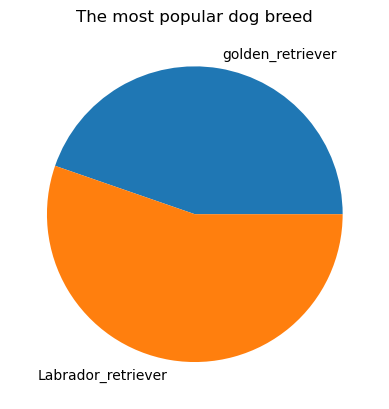

In [2018]:
# make a pie chart to know which one is the most popular
data = [p1.max(),p2.max() + p3.max()]
labels = [p1.idxmax(),p2.idxmax()]
plt.pie(data,labels=labels)
plt.title('The most popular dog breed')
plt.show()

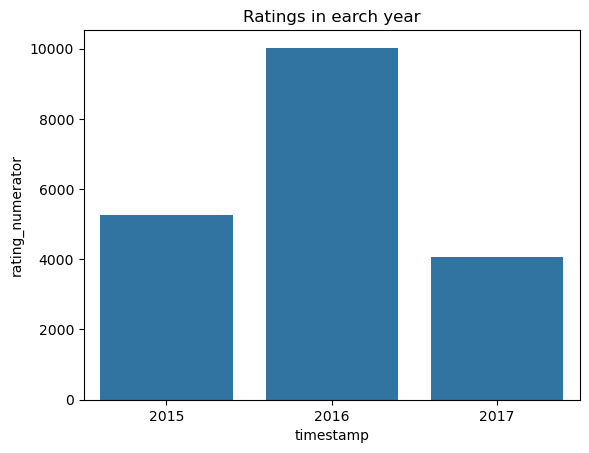

In [2022]:
# plot the ratings in each year
sns.barplot(rating_year)
plt.title('Ratings in earch year')
plt.show()